# BosonSR Annihilation: Basic Analysis

This notebook runs a compact smoke-analysis of the non-CBC `BosonSR_ann` waveform: source polarizations, detector strain, SNR, and a small Fisher matrix.

In [1]:
using Pkg
project_dir = pwd()
Pkg.activate(project_dir)

include(joinpath(project_dir, "src", "GW.jl"))
using .GW
using Plots

default(size=(850, 420), linewidth=2, grid=true)

  Activating project at `~/GW_free_params.jl`


## Waveform and Parameters

`dL` is in Gpc in GWJulia. The value below is intentionally nearby (`1e-6` Gpc = 1 kpc) so the line is easy to inspect.

In [8]:
model = BosonSR_ann()

M_solar = 1000.0
mua = 2.0e-21
intrinsic = (M_solar, mua)

dL = 1.0e-6
theta = 1.0
phi = 2.0
iota = 0.4
psi = 0.7
tcoal = 0.2
phiCoal = 0.0
phase0 = 0.0

f_line = GW.waveform._ann_line_frequency(M_solar, mua)
fmin = max(2.0, 0.7 * f_line)
fmax = 1.3 * f_line
f = collect(range(fmin, fmax, length=800))

println("available non-CBC model: ", _available_waveforms("BosonSR_ann"))
println("parameter names: ", GW.waveform._parameter_names(model))
println("line frequency [Hz]: ", f_line)
println("analysis band [Hz]: ", (first(f), last(f)))

## Source-Frame Polarizations

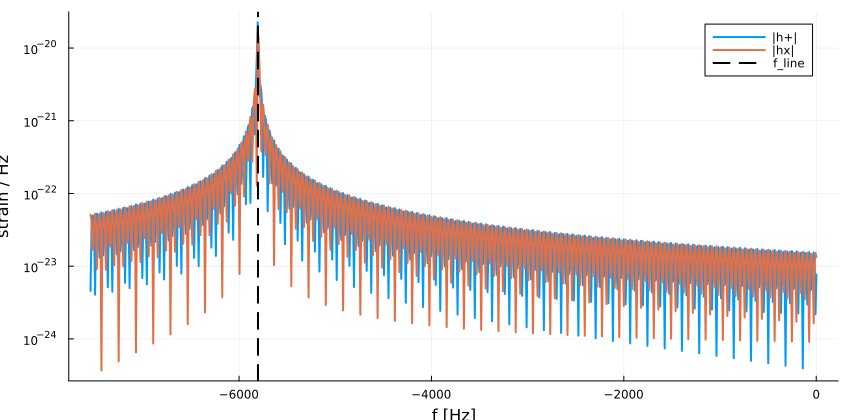

In [9]:
h_plus, h_cross = Pol(model, f, intrinsic, dL, iota, phase0)

plot(f, abs.(h_plus), label="|h+|", xlabel="f [Hz]", ylabel="strain / Hz", yscale=:log10)
plot!(f, abs.(h_cross), label="|hx|")
vline!([f_line], label="f_line", linestyle=:dash, color=:black)

## Detector Strain

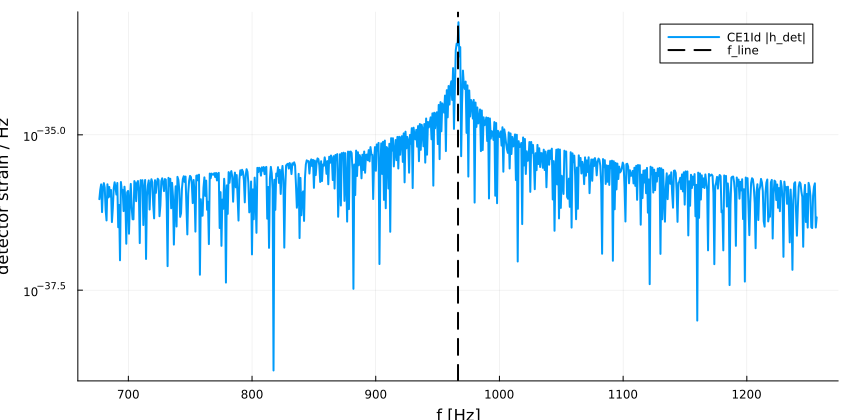

In [4]:
strain_ce = Strain(
    model,
    CE1Id_coordinates,
    f,
    intrinsic,
    dL,
    theta,
    phi,
    iota,
    psi,
    tcoal,
    phiCoal,
    phase0,
)

plot(f, abs.(strain_ce), label="CE1Id |h_det|", xlabel="f [Hz]", ylabel="detector strain / Hz", yscale=:log10)
vline!([f_line], label="f_line", linestyle=:dash, color=:black)

## SNR

In [5]:
collect(mua_range)

UndefVarError: UndefVarError: `mua_range` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [7]:
network = [ETLS, ETLMR, CE1Id]

M_solar = 10.0
mua = 2.0e-21
intrinsic = (M_solar, mua)
M_solar_range = 1:10:1000  
mua_range = 10. .^(-22:0.1:-19) *2.
snr_matrix = zeros(length(M_solar_range), length(mua_range))
for (i, M_solar_i) in enumerate(M_solar_range)
    for (j, mua_j) in enumerate(mua_range)
        intrinsic = (M_solar_i, mua_j)
        snr_ij = NaN
        #try
            snr_ij = SNR(
            model,
            network,
            intrinsic,
            dL,
            theta,
            phi,
            iota,
            psi,
            tcoal;
            fmin=fmin,
            fmax=fmax,
            res=80,
        )
        # catch e
        #     @warn "SNR calculation failed for M_solar=$M_solar_i, mua=$mua_j, error: $e"
        #     #snr_ij = NaN
        # end
        
        snr_matrix[i, j] = snr_ij
    end
end

DomainError: DomainError with -1.2571081054087107e-40:
sqrt was called with a negative real argument but will only return a complex result if called with a complex argument. Try sqrt(Complex(x)).
DomainError detected in the user `f` function. This occurs when the domain of a function is violated.
For example, `log(-1.0)` is undefined because `log` of a real number is defined to only output real
numbers, but `log` of a negative number is complex valued and therefore Julia throws a DomainError
by default. Cases to be aware of include:

* `log(x)`, `sqrt(x)`, `cbrt(x)`, etc. where `x<0`
* `x^y` for `x<0` floating point `y` (example: `(-1.0)^(1/2) == im`)

Within the context of SciML, this error can occur within the solver process even if the domain constraint
would not be violated in the solution due to adaptivity. For example, an ODE solver or optimization
routine may check a step at `new_u` which violates the domain constraint, and if violated reject the
step and use a smaller `dt`. How

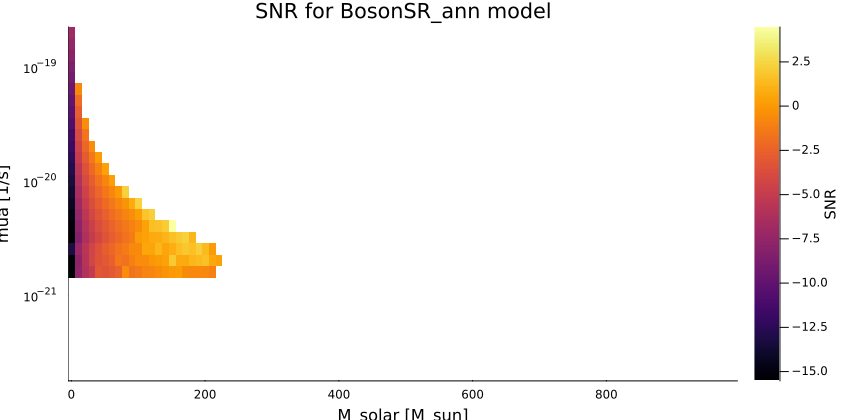

In [61]:
fig = heatmap(
    M_solar_range,
    mua_range,
    log10.(snr_matrix)';
    ylabel="mua [1/s]",
    xlabel="M_solar [M_sun]",
    title="SNR for BosonSR_ann model",
    colorbar_title="SNR",
    #xlims = (10, 250),
    yscale = :log10
)

## Small Fisher Matrix

This is intentionally low resolution. Increase `res` after the smoke run is stable.

9×9 Matrix{Float64}:
  7.3e43       1.33912e65   5.76696e17   …   2.44199e8    -2.60192e-6
  1.33912e65   8.17451e89   1.94729e41      -5.64175e32   -1.06772e19
  5.76696e17   1.94729e41   2.0632e-5        1.91649e-15  -3.14644e-28
 -5.24748e12   1.57874e37  -2.5379e-12       1.51398e-11  -2.49409e-15
 -3.35797e12   7.75797e36  -2.63537e-11      4.07994e-12  -6.72117e-16
  2.59465e11   3.18865e34   8.69491e-12  …   8.43583e-22  -3.56931e-35
  6.23291e12  -1.94751e37  -4.61044e-12      1.34803e-20   1.86483e-34
  2.44199e8   -5.64175e32   1.91649e-15      7.60183e-10  -1.2523e-13
 -2.60192e-6  -1.06772e19  -3.14644e-28     -1.2523e-13    2.0632e-17

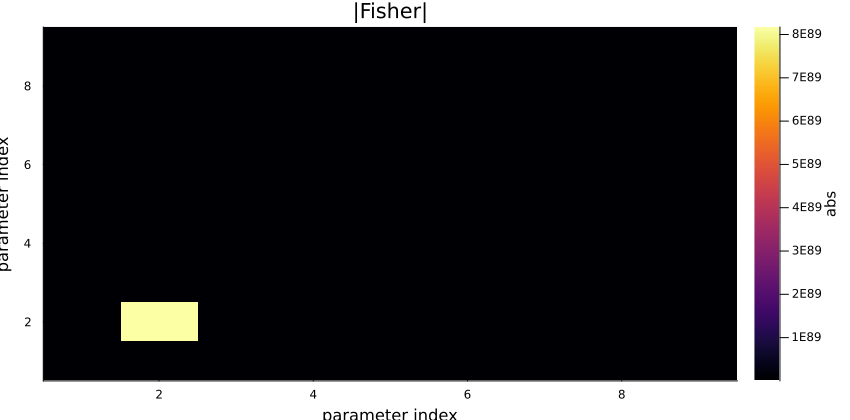

In [8]:
fisher = FisherMatrix(
    model,
    CE1Id,
    intrinsic,
    dL,
    theta,
    phi,
    iota,
    psi,
    tcoal,
    phiCoal;
    res=800,
    fmin=fmin,
    fmax=fmax,
    rho_thres=nothing,
)

display(fisher)
heatmap(abs.(fisher), xlabel="parameter index", ylabel="parameter index", title="|Fisher|", colorbar_title="abs")